[\[GitHub\] Jupyter Notebook](https://github.com/sslastochkin/mcab/blob/main/docs/guide/11_empirical_tests.ipynb)

# Empirical Tests  
  
In A/B testing, **empirical (simulation-based) tests** compute p-values by building a null distribution through resampling — not through a formula. This makes them:
  
- **Distribution-free**: no normality assumption, work well on skewed or heavy-tailed data
- **Flexible**: plug in any statistic (mean, median, custom)
- **Interpretable**: the null distribution is explicit and visualizable

This section covers six functions from `mcab.mstats`:

| Function | Type | Use case |
|---|---|---|
| `bootstrap_1s` | one-sample | Test if a single sample's statistic = 0 |
| `bootstrap_2s` | two-sample independent | Test if two groups differ (any statistic) |
| `permutation_test_2s` | two-sample independent | Same, but by permuting labels |
| `sign_permutation_test` | paired (dependent) | Test paired differences (pre/post, matched) |
| `bucket_test_2s` | two-sample independent | Fast aggregation-based test for large samples |
| `delta_method_pvalue` | two-sample ratio metric | Test CTR-like metrics (numerator / denominator) |

All functions return a **p-value** by default. Pass `alternative='interval'` to get the raw null distribution instead (useful for confidence intervals and visualization).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from mcab.mstats import (
    bootstrap_1s,
    bootstrap_2s,
    bucket_test_2s,
    delta_method_pvalue,
    permutation_test_2s,
    sign_permutation_test,
)

RNG = np.random.default_rng(42)

# --- Independent two-sample data ---
# Slightly shifted means, exponential distribution (skewed)
n = 1_000
control = RNG.exponential(scale=1.0, size=n)
test    = RNG.exponential(scale=1.07, size=n)  # +7% effect

# --- Paired data (pre/post measurements) ---
n_pairs = 500
pre  = RNG.normal(loc=10.0, scale=2.0, size=n_pairs)
post = pre + RNG.normal(loc=0.3, scale=1.5, size=n_pairs)  # small positive shift
d    = post - pre  # paired differences

# --- Ratio metric data (e.g. CTR: clicks / impressions) ---
n_ratio = 2_000
ctrl_impressions = RNG.poisson(lam=10, size=n_ratio).astype(float) + 1
ctrl_clicks      = RNG.binomial(n=ctrl_impressions.astype(int), p=0.05)

test_impressions = RNG.poisson(lam=10, size=n_ratio).astype(float) + 1
test_clicks      = RNG.binomial(n=test_impressions.astype(int), p=0.055)  # +10% CTR

print(f"control mean:   {control.mean():.4f}")
print(f"test    mean:   {test.mean():.4f}")
print(f"paired  d mean: {d.mean():.4f}")
print(f"ctrl CTR: {ctrl_clicks.sum()/ctrl_impressions.sum():.4f}")
print(f"test CTR: {test_clicks.sum()/test_impressions.sum():.4f}")


control mean:   1.0144
test    mean:   1.0867
paired  d mean: 0.3835
ctrl CTR: 0.0497
test CTR: 0.0578


## `bootstrap_1s` — One-Sample Bootstrap Test

**Hypothesis**: H₀: `statistic(x) = 0`

The test resamples `x` with replacement `n_bootstrap` times and builds a null distribution
by **centering** the bootstrap statistics at zero (reflecting around the observed value).
The p-value is the fraction of bootstrap statistics at least as extreme as the observed one.

**When to use**: when you have a single sample and want to test whether its mean (or another
statistic) equals zero — e.g., testing a vector of per-user treatment effects.

**Key parameters**:  
  
- `statistic` — any callable, default `np.mean`
- `n_bootstrap` — number of resamples (5 000 is a good default; use 10 000+ for publication)
- `alternative` — `'two-sided'` / `'greater'` / `'less'` / `'interval'`
- `n_jobs` — parallelism; use `-1` only when `n_bootstrap ≥ 5 000` and sample size ≥ 1 000
- `rng` — int seed or `np.random.Generator` for reproducibility


In [2]:
# bootstrap_1s: basic usage

# Scenario: d is a vector of paired differences.
# H0: mean(d) = 0. We expect to reject since mean(d) ≈ 0.3.

pval_two = bootstrap_1s(d, statistic=np.mean,   n_bootstrap=5_000, rng=42)
pval_gt  = bootstrap_1s(d, statistic=np.mean,   n_bootstrap=5_000, rng=42, alternative='greater')
pval_med = bootstrap_1s(d, statistic=np.median, n_bootstrap=5_000, rng=42)

print(f"bootstrap_1s  two-sided  (mean):   p = {pval_two:.4f}")
print(f"bootstrap_1s  greater    (mean):   p = {pval_gt:.4f}")
print(f"bootstrap_1s  two-sided  (median): p = {pval_med:.4f}")


bootstrap_1s  two-sided  (mean):   p = 0.0004
bootstrap_1s  greater    (mean):   p = 0.0002
bootstrap_1s  two-sided  (median): p = 0.0004


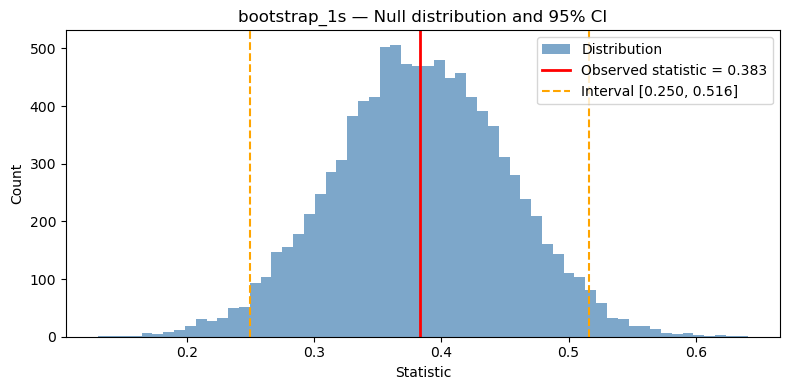

95% bootstrap CI: [0.250, 0.516]
CI excludes zero: True


In [3]:
def plot_dist(boot_dist, obs_stat, ci_lo, ci_hi, title):
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(boot_dist, bins=60, color='steelblue', alpha=0.7,
                label='Distribution')
        ax.axvline(obs_stat, color='red',    lw=2,
                label=f'Observed statistic = {obs_stat:.3f}')
        ax.axvline(ci_lo, color='orange', lw=1.5, linestyle='--',
                label=f'Interval [{ci_lo:.3f}, {ci_hi:.3f}]')
        ax.axvline(ci_hi, color='orange', lw=1.5, linestyle='--')
        ax.set_xlabel('Statistic')
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()

# bootstrap_1s: null distribution + confidence interval

boot_dist = bootstrap_1s(d, n_bootstrap=10_000, rng=42, alternative='interval')

obs_stat     = np.mean(d)
ci_lo, ci_hi = np.percentile(boot_dist, [2.5, 97.5])

plot_dist(boot_dist, obs_stat, ci_lo, ci_hi, 'bootstrap_1s — Null distribution and 95% CI')

print(f"95% bootstrap CI: [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"CI excludes zero: {ci_lo > 0}")


## `bootstrap_2s` — Two-Sample Bootstrap Test

**Hypothesis**: H₀: `statistic(test) = statistic(control)`

Both groups are resampled **independently** with replacement. The null distribution
is built from `stat(boot_test) − stat(boot_control)` across all resamples.

**When to use**: independent A/B groups, any statistic (mean, median, 90th percentile, etc.).

**Difference from `permutation_test_2s`**:  
  
- Bootstrap resamples each group separately → works even when groups are of very different sizes and distributions
- Permutation test pools observations and reassigns labels → more conservative, makes a stronger exchangeability assumption

**Key parameters**: same as `bootstrap_1s`, plus `test` and `control` arrays.
Pass `alternative='interval'` to get the distribution of `stat(test) − stat(control)`.


In [ ]:
# bootstrap_2s: basic usage

pval_mean   = bootstrap_2s(test, control, statistic=np.mean,   n_bootstrap=5_000, rng=42)
pval_median = bootstrap_2s(test, control, statistic=np.median, n_bootstrap=5_000, rng=42)

# Custom statistic: 90th percentile
p90      = lambda x: np.percentile(x, 90)
pval_p90 = bootstrap_2s(test, control, statistic=p90, n_bootstrap=5_000, rng=42)

print(f"bootstrap_2s  mean:    p = {pval_mean:.4f}")
print(f"bootstrap_2s  median:  p = {pval_median:.4f}")
print(f"bootstrap_2s  90th %:  p = {pval_p90:.4f}")


bootstrap_2s  mean:    p = 0.1320
bootstrap_2s  median:  p = 0.1040
bootstrap_2s  90th %:  p = 0.9906


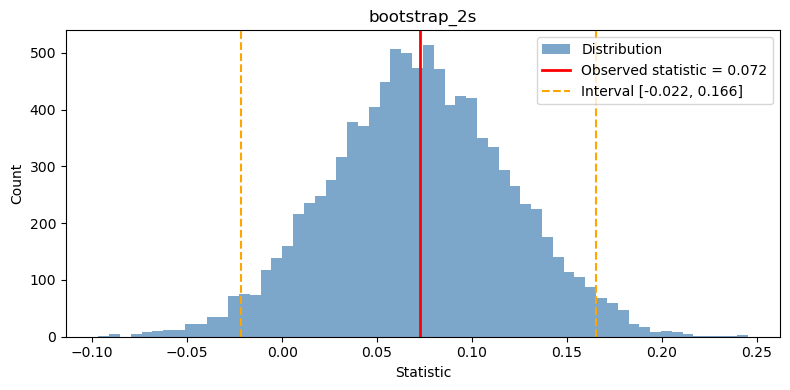

95% bootstrap CI on difference: [-0.022, 0.166]


In [5]:
# bootstrap_2s: null distribution + CI on the difference

boot_diff    = bootstrap_2s(test, control, n_bootstrap=10_000, rng=42, alternative='interval')
obs_diff     = np.mean(test) - np.mean(control)
ci_lo, ci_hi = np.percentile(boot_diff, [2.5, 97.5])

plot_dist(boot_diff, obs_diff, ci_lo, ci_hi, 'bootstrap_2s')

print(f"95% bootstrap CI on difference: [{ci_lo:.3f}, {ci_hi:.3f}]")


## `permutation_test_2s` — Two-Sample Permutation Test

**Hypothesis**: H₀: `statistic(test) = statistic(control)` (observations are exchangeable)

The test **pools** all `n_test + n_control` observations and randomly reassigns group labels
`n_perm` times. Under H₀, the group assignment carries no information, so the observed
difference should be typical of the permutation distribution.

**When to use**:  
  
- Independent A/B groups
- You believe the null truly implies exchangeability (same distribution, not just same mean)
- When you want a test that is slightly more conservative than bootstrap

**Parallelism**: for `n_perm ≥ 5 000` and sample sizes 5 000–20 000, `n_jobs=-1` gives 2–4× speedup.
For very small or very large samples, single-threaded (`n_jobs=1`) is often faster due to overhead.


permutation_test_2s:  p = 0.1319
bootstrap_2s:         p = 0.1282
Both tests should agree closely for typical sample sizes.


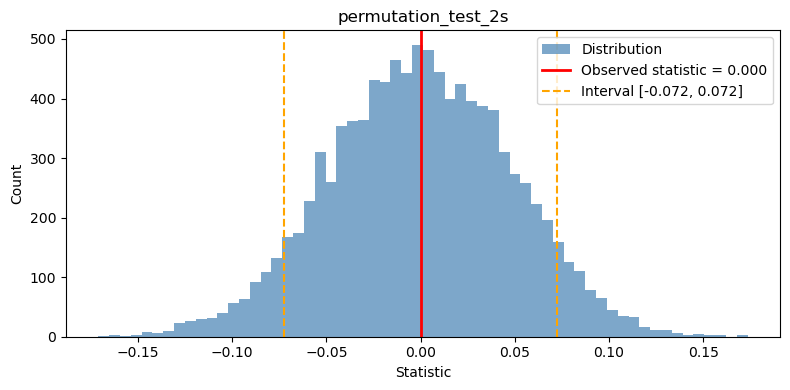

In [ ]:
# permutation_test_2s: comparison with bootstrap

pval_perm = permutation_test_2s(test, control, n_perm=10_000, rng=42)
pval_boot = bootstrap_2s(test, control, n_bootstrap=10_000, rng=42)

print(f"permutation_test_2s:  p = {pval_perm:.4f}")
print(f"bootstrap_2s:         p = {pval_boot:.4f}")
print("Both tests should agree closely for typical sample sizes.")

# null distribution visualization
perm_dist = permutation_test_2s(
    test, control, n_perm=10_000, rng=42, alternative='interval'
)
obs_diff = np.mean(test) - np.mean(control)

plot_dist(perm_dist, 0, -obs_diff, obs_diff, 'permutation_test_2s')

## `sign_permutation_test` — Paired Sign-Permutation Test

**Hypothesis**: H₀: distribution of `d` is symmetric around zero (E[d] = 0)

Given paired differences `d = test − control`, the test randomly flips the **sign** of each
`d_i` with probability 0.5. Under H₀ (no treatment effect), positive and negative differences
are equally likely.

**When to use**:  
  
- **Paired / matched-pairs** experiments (same user measured before and after, or users matched by propensity score)
- **Not** for independent two-sample tests — use `permutation_test_2s` or `bootstrap_2s` instead

**Input**: `d` — a 1-D array of per-pair differences, e.g. `post − pre` or
`test_user_value − control_user_value`.

**Comparison with `bootstrap_1s`**:  
  
| | `sign_permutation_test` | `bootstrap_1s` |
|---|---|---|
| Mechanism | Random sign flips | Resample with replacement |
| Assumption | Symmetry of d around 0 | None |
| CI support | Via `alternative='interval'` | Via `alternative='interval'` |
| Typically | Slightly more conservative | Slightly more liberal |


sign_permutation_test  two-sided: p = 0.0000
sign_permutation_test  greater:   p = 0.0000
bootstrap_1s           two-sided: p = 0.0002


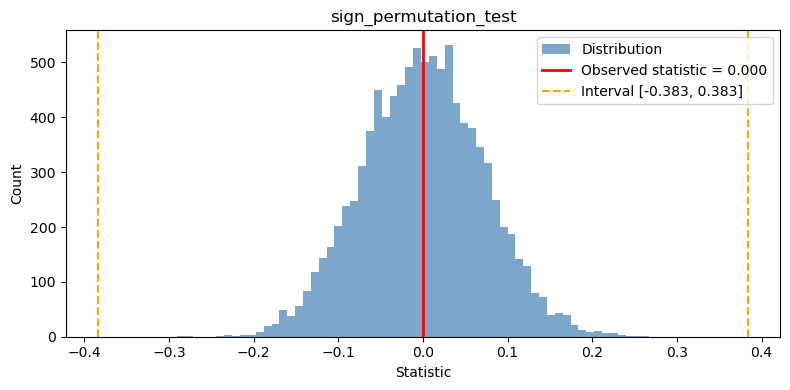

In [15]:
# sign_permutation_test: basic usage + comparison with bootstrap_1s

pval_sign    = sign_permutation_test(d, n_perm=10_000, rng=42)
pval_sign_gt = sign_permutation_test(d, n_perm=10_000, rng=42, alternative='greater')
pval_boot1s  = bootstrap_1s(d, n_bootstrap=10_000, rng=42)

print(f"sign_permutation_test  two-sided: p = {pval_sign:.4f}")
print(f"sign_permutation_test  greater:   p = {pval_sign_gt:.4f}")
print(f"bootstrap_1s           two-sided: p = {pval_boot1s:.4f}")

# null distribution
sign_dist = sign_permutation_test(
    d, n_perm=10_000, rng=42, alternative='interval'
)
obs_mean = np.mean(d)

plot_dist(sign_dist, 0, -obs_mean, obs_mean, 'sign_permutation_test')

## `bucket_test_2s` — Two-Sample Bucket (Aggregation) Test

**Hypothesis**: H₀: `statistic(test) = statistic(control)` (via aggregated bucket statistics)

Each group is randomly split into `n_buckets` non-overlapping buckets. A `statistic`
(default: `np.mean`) is computed within each bucket. The resulting `n_buckets` aggregated
values per group are compared with a user-supplied `pval_func`.

**Why it works**: by the Central Limit Theorem, bucket means are approximately normal even
when raw observations are heavily skewed. A t-test on bucket means is therefore valid.

**When to use**:  
  
- Large samples (100 000+) where bootstrap/permutation is slow
- Heavy-tailed distributions where a raw t-test is unreliable
- When you want a fast, approximate test with good power

**Choosing `n_buckets`**: more buckets → more degrees of freedom for `pval_func`, but each
bucket is smaller (weaker CLT). Typical range: 50–500. Rule of thumb: `n_buckets ≈ sqrt(n)`.

**`pval_func`**: any callable `(array_a, array_b) → float`. Common choices:  
  
- Welch t-test: `lambda t, c: stats.ttest_ind(t, c, equal_var=False).pvalue`
- Mann-Whitney: `lambda t, c: stats.mannwhitneyu(t, c).pvalue`


In [ ]:
# bucket_test_2s: Welch t-test and Mann-Whitney on bucket statistics

pval_func_welch = lambda t, c: stats.ttest_ind(t, c, equal_var=False).pvalue
pval_func_mwu   = lambda t, c: stats.mannwhitneyu(t, c).pvalue

pval_bucket_100 = bucket_test_2s(
    test, control,
    pval_func=pval_func_welch,
    n_buckets=100,
    rng=42,
)
pval_bucket_200 = bucket_test_2s(
    test, control,
    pval_func=pval_func_welch,
    n_buckets=200,
    rng=42,
)
pval_bucket_mwu = bucket_test_2s(
    test, control,
    pval_func=pval_func_mwu,
    n_buckets=100,
    rng=42,
)

print(f"bucket_test_2s  n_buckets=100  Welch:        p = {pval_bucket_100:.4f}")
print(f"bucket_test_2s  n_buckets=200  Welch:        p = {pval_bucket_200:.4f}")
print(f"bucket_test_2s  n_buckets=100  Mann-Whitney: p = {pval_bucket_mwu:.4f}")


bucket_test_2s  n_buckets=100  Welch:        p = 0.1169
bucket_test_2s  n_buckets=200  Welch:        p = 0.1185
bucket_test_2s  n_buckets=100  Mann-Whitney: p = 0.1410


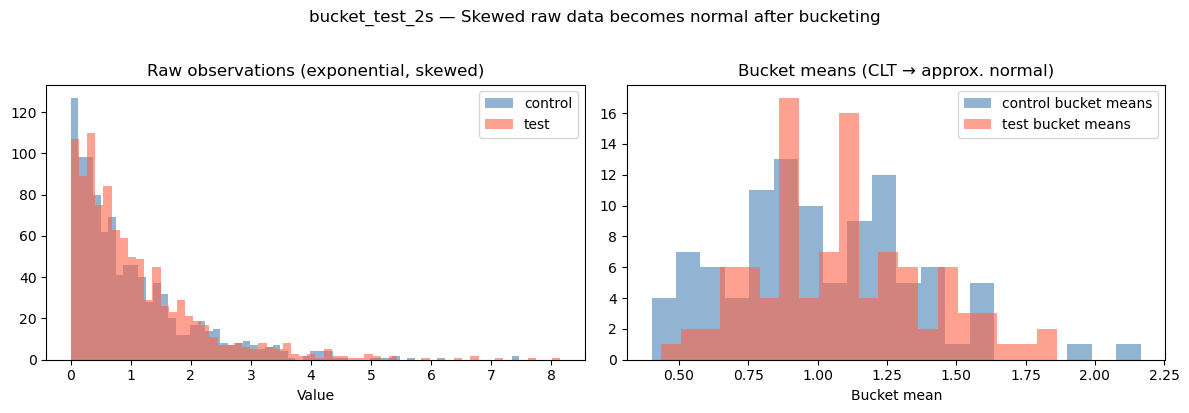

In [ ]:
# bucket_test_2s: CLT effect — from skewed raw data to normal buckets

rng_vis = np.random.default_rng(0)

def get_bucket_means(x, n_buckets=100):
    shuffled = x[rng_vis.permutation(len(x))]
    return [chunk.mean() for chunk in np.array_split(shuffled, n_buckets)]

test_buckets    = get_bucket_means(test)
control_buckets = get_bucket_means(control)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(control, bins=60, alpha=0.6, color='steelblue', label='control')
axes[0].hist(test,    bins=60, alpha=0.6, color='tomato',    label='test')
axes[0].set_title('Raw observations (exponential, skewed)')
axes[0].set_xlabel('Value')
axes[0].legend()

axes[1].hist(control_buckets, bins=20, alpha=0.6, color='steelblue', label='control bucket means')
axes[1].hist(test_buckets,    bins=20, alpha=0.6, color='tomato',    label='test bucket means')
axes[1].set_title('Bucket means (CLT → approx. normal)')
axes[1].set_xlabel('Bucket mean')
axes[1].legend()

plt.suptitle('bucket_test_2s — Skewed raw data becomes normal after bucketing', y=1.02)
plt.tight_layout()
plt.show()


## `delta_method_pvalue` — Ratio Metric Test

**Hypothesis**: H₀: `mean(num_test)/mean(denom_test) = mean(num_ctrl)/mean(denom_ctrl)`

The **delta method** analytically approximates the variance of a ratio `mean(numerator) / mean(denominator)`
using a first-order Taylor expansion. The difference between two such ratios is then compared
with a standard normal (z) test.

**When to use**:  
  
- Metrics defined as ratios: CTR (clicks/impressions), ARPU (revenue/users), conversion rate
- The numerator and denominator are **correlated within the same user** — a simple t-test on
  per-user ratios would not account for this correlation correctly at the aggregate level

**Input**: `test` and `control` are each a **tuple** `(num_array, denom_array)`.

**Output**: `(pvalue, delta)` — the p-value and the raw difference of ratio metrics.

> ⚠️ The delta method is a **parametric approximation** valid for large samples.
> For small samples, prefer `bootstrap_2s` with a custom ratio statistic.


In [ ]:
# delta_method_pvalue: CTR-like ratio metric

pvalue, delta = delta_method_pvalue(
    test    = (test_clicks, test_impressions),
    control = (ctrl_clicks, ctrl_impressions),
)

ctrl_ctr = ctrl_clicks.sum() / ctrl_impressions.sum()
test_ctr = test_clicks.sum() / test_impressions.sum()

print(f"Control CTR:        {ctrl_ctr:.4f}")
print(f"Test CTR:           {test_ctr:.4f}")
print(f"Delta (test−ctrl):  {delta:.5f}  ({delta/ctrl_ctr*100:.1f}% relative lift)")
print(f"p-value:            {pvalue:.4f}")


Control CTR:        0.0497
Test CTR:           0.0578
Delta (test−ctrl):  0.00809  (16.3% relative lift)
p-value:            0.0002


In [ ]:
# delta_method_pvalue vs bootstrap_2s on per-user CTR

# Simple alternative: treat per-user CTR as independent observations
ctrl_per_user = ctrl_clicks / ctrl_impressions
test_per_user = test_clicks / test_impressions

pval_boot_ratio = bootstrap_2s(
    test_per_user, ctrl_per_user,
    statistic=np.mean,
    n_bootstrap=5_000,
    rng=42,
)

print(f"delta_method_pvalue:         p = {pvalue:.4f}  (joint num/denom model)")
print(f"bootstrap_2s (per-user CTR): p = {pval_boot_ratio:.4f}  (independent per-user ratios)")
print()
print("delta_method_pvalue correctly models the covariance between numerator and denominator.")
print("bootstrap_2s on per-user CTR is simpler but treats each user's ratio as independent.")


delta_method_pvalue:         p = 0.0002  (joint num/denom model)
bootstrap_2s (per-user CTR): p = 0.0004  (independent per-user ratios)

delta_method_pvalue correctly models the covariance between numerator and denominator.
bootstrap_2s on per-user CTR is simpler but treats each user's ratio as independent.


## Choosing the Right Test

```
Is your data paired (matched users, pre/post)?
  ├─ YES → sign_permutation_test(d)  or  bootstrap_1s(d)
  └─ NO  (independent groups)
       │
       Is your metric a ratio (CTR, ARPU, revenue/session)?
         ├─ YES → delta_method_pvalue((num_t, denom_t), (num_c, denom_c))
         └─ NO
              │
              Is your sample very large (100k+) and speed matters?
                ├─ YES → bucket_test_2s(test, control, pval_func=...)
                └─ NO
                     │
                     Do you need a non-mean statistic (median, percentile)?
                       ├─ YES → bootstrap_2s(test, control, statistic=...)
                       └─ NO (testing means)
                            ├─ permutation_test_2s  (more conservative, exchangeability)
                            └─ bootstrap_2s         (slightly more liberal, no exchangeability needed)
```

### Summary of tradeoffs

| Function | Speed | Distributional assumption | Paired? | Custom statistic |
|---|---|---|---|---|
| `bootstrap_1s` | Medium | None | ✅ (pass `d`) | ✅ |
| `bootstrap_2s` | Medium | None | ❌ | ✅ |
| `permutation_test_2s` | Medium | Exchangeability under H₀ | ❌ | ✅ |
| `sign_permutation_test` | Medium | Symmetry of d around 0 | ✅ | ✅ |
| `bucket_test_2s` | **Fast** | CLT within buckets | ❌ | ✅ |
| `delta_method_pvalue` | **Fastest** | Large-sample (CLT on ratio) | ❌ | ❌ (ratio only) |

All simulation-based functions accept `rng` (int or `np.random.Generator`) for reproducibility
and `n_jobs` for parallelism (`-1` = all CPUs, best for `n_bootstrap/n_perm ≥ 5 000` with large samples).